# Análisis Inferencial


* Luisa Merlo García | A01067715
* Edgar Osvaldo Navarro | A01644488
* Ariana Guadalupe Rosales Villalobos | A01644773


## Ejercicio 1 (60 puntos)

La base de datos Palmer PenguinsDescargar Palmer Penguins contiene información sobre 344 pingüinos observados en el archipiélago Palmer, en la Antártida. Incluye ejemplares de tres especies distintas y registra tanto características físicas como información sobre el lugar y el año de observación, por lo que permite comparar grupos y estudiar relaciones entre variables.

Para esta base de datos, analiza lo siguiente:

### A. Masa corporal

Analiza la variable masa corporal (body_mass_g) y realiza lo siguiente:

* Analiza la masa corporal considerando simultáneamente los factores especie y sexo. Determina si existe un efecto significativo de la especie, un efecto significativo del sexo y una interacción significativa entre ambos factores.


In [17]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

penguins = pd.read_csv("penguins.txt")

penguins.groupby("species")["body_mass_g"].count()

species
Adelie       151
Chinstrap     68
Gentoo       123
Name: body_mass_g, dtype: int64

In [18]:
# Construye un intervalo de confianza del 95 % para la  masa corporal media de todos los pingüinos.
body_mass = penguins["body_mass_g"].dropna()

x = body_mass
cl = 0.95
alpha = 1 - cl

# Calcular std y media poblacional
sample_mean = np.mean(x)
sample_std_dev = np.std(x, ddof=1)
sample_size = len(x)

# Calcular el valor critico de distribucion t
t_score = stats.t.ppf(1 - alpha/2, df=sample_size - 1)

# Calcular el margen de error y el intervalo de confianza
margin_of_error = t_score * sample_std_dev / np.sqrt(sample_size)

confidence_interval = (
    sample_mean - margin_of_error,
    sample_mean + margin_of_error
)

print("Sample size =", sample_size)
print("Sample mean =", sample_mean)
print("Desviación estándar de la muestra =", sample_std_dev)
print("t-score =", t_score)
print("Margen de error =", margin_of_error)
print("95% Intervalo de confianza =", confidence_interval)

Sample size = 342
Sample mean = 4201.754385964912
Desviación estándar de la muestra = 801.9545356980955
t-score = 1.9669451293272178
Margen de error = 85.29605394086734
95% Intervalo de confianza = (np.float64(4116.4583320240445), np.float64(4287.05043990578))


In [19]:
## Construye intervalos de confianza del 95 % para la masa corporal media de cada especie.
species_list = penguins["species"].unique()

cl = 0.95
alpha = 1 - cl

for species in species_list:
    
    # Seleccionar los valores de masa corporal de las especies
    x = penguins.loc[
        penguins["species"] == species,
        "body_mass_g"
    ].dropna()

    # Estadísticas de la muestra
    sample_mean = np.mean(x)
    sample_std_dev = np.std(x, ddof=1)
    sample_size = len(x)

    # Calcular el valor crítico de la distribución t
    t_score = stats.t.ppf(
        1 - alpha/2,
        df=sample_size - 1
    )

    # Margen de error
    margin_of_error = (
        t_score
        * sample_std_dev
        / np.sqrt(sample_size)
    )

    # Intervalo de confianza
    confidence_interval = (
        sample_mean - margin_of_error,
        sample_mean + margin_of_error
    )

    print(species)
    print("Sample size =", sample_size)
    print("Sample mean =", sample_mean)
    print("95% Intervalo de confianza =", confidence_interval)
    print()

Adelie
Sample size = 151
Sample mean = 3700.662251655629
95% Intervalo de confianza = (np.float64(3626.926242277889), np.float64(3774.398261033369))

Gentoo
Sample size = 123
Sample mean = 5076.016260162602
95% Intervalo de confianza = (np.float64(4986.034279556633), np.float64(5165.99824076857))

Chinstrap
Sample size = 68
Sample mean = 3733.0882352941176
95% Intervalo de confianza = (np.float64(3640.0593266448386), np.float64(3826.1171439433965))



In [20]:
## Construye un intervalo de confianza del 95 % para la diferencia de masa corporal media entre machos y hembras.


male = penguins.loc[
    penguins["sex"] == "male",
    "body_mass_g"
].dropna()

female = penguins.loc[
    penguins["sex"] == "female",
    "body_mass_g"
].dropna()

cl = 0.95
alpha = 1 - cl

# Calcular la media y desviación estándar de cada grupo
mean_male = np.mean(male)
std_male = np.std(male, ddof=1)

mean_female = np.mean(female)
std_female = np.std(female, ddof=1)

n_male = len(male)
n_female = len(female)

# Calcular el error estándar de la diferencia de medias
standard_error_diff = np.sqrt(
    std_male**2 / n_male +
    std_female**2 / n_female
)

# grados d confiaza Welch-Satterwhaite
df = (
    std_male**2 / n_male +
    std_female**2 / n_female
)**2 / (
    (std_male**2 / n_male)**2 / (n_male - 1)
    +
    (std_female**2 / n_female)**2 / (n_female - 1)
)

# valor critico t 
t_score = stats.t.ppf(1 - alpha/2, df=df)

# Magen de error
margin_of_error_diff = t_score * standard_error_diff

# Intervalo de confianza para macho y hembra
confidence_interval_diff = (
    mean_male - mean_female - margin_of_error_diff,
    mean_male - mean_female + margin_of_error_diff
)

print("Macho sample size =", n_male)
print("Hembra sample size =", n_female)

print("Promedio macho =", mean_male)
print("Promedio hembra =", mean_female)

print("Diferencia macho - hembra =", mean_male - mean_female)

print("Grados de libertad =", df)

print(
    "95% Intervalo de confianza para macho - hembra =",
    confidence_interval_diff
)

Macho sample size = 168
Hembra sample size = 165
Promedio macho = 4545.684523809524
Promedio hembra = 3862.2727272727275
Diferencia macho - hembra = 683.4117965367964
Grados de libertad = 323.8958810286484
95% Intervalo de confianza para macho - hembra = (np.float64(526.2453315709475), np.float64(840.5782615026452))


In [21]:
## Evalúa el supuesto de normalidad de la masa corporal para cada especie mediante una prueba de normalidad apropiada. Complementa el resultado con una inspección gráfica, por ejemplo mediante histogramas o gráficos Q–Q.


alpha = 0.05

species_list = penguins["species"].unique()

for species in species_list:

    x = penguins.loc[
        penguins["species"] == species,
        "body_mass_g"
    ].dropna()

    shapiro_stat, p_value = stats.shapiro(x)

    print(species)
    print("n =", len(x))
    print("Shapiro-Wilk estadístico =", shapiro_stat)
    print("p-value =", p_value)

    if p_value < alpha:
        print("Rechazar H0: evidencia en contra de la normalidad")
    else:
        print("No se rechaza H0: la normalidad es razonable")

    print()

Adelie
n = 151
Shapiro-Wilk estadístico = 0.9807078505542097
p-value = 0.03239702371600242
Rechazar H0: evidencia en contra de la normalidad

Gentoo
n = 123
Shapiro-Wilk estadístico = 0.9859276066123654
p-value = 0.23361648652088396
No se rechaza H0: la normalidad es razonable

Chinstrap
n = 68
Shapiro-Wilk estadístico = 0.9844937616682576
p-value = 0.5605082384431727
No se rechaza H0: la normalidad es razonable



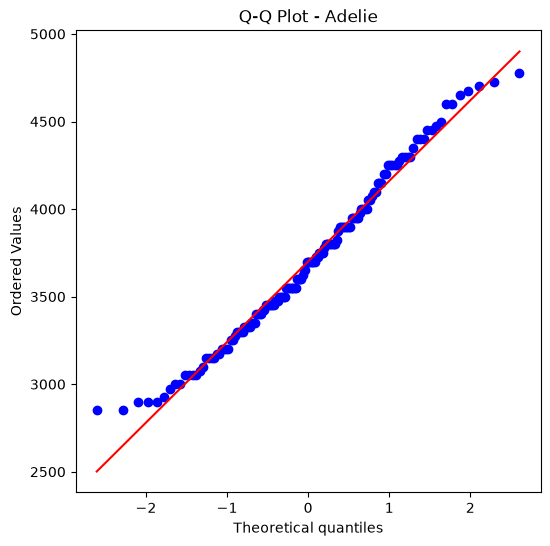

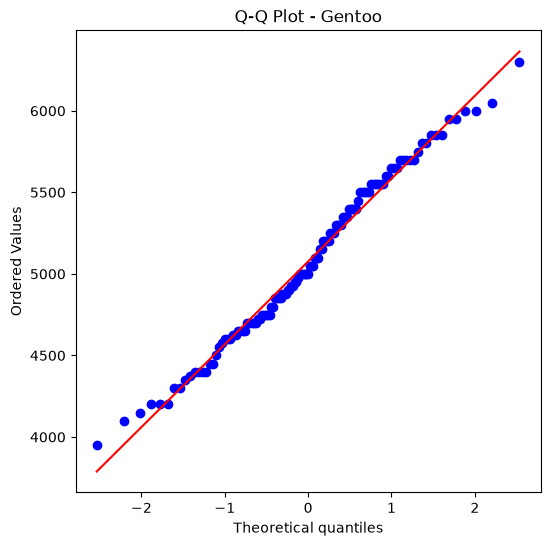

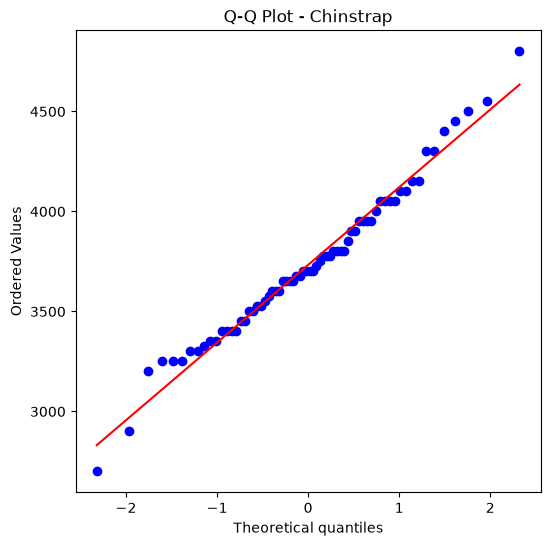

In [ ]:
## Gráfico de Q-Q para cada especie

for species in species_list:

    x = penguins.loc[
        penguins["species"] == species,
        "body_mass_g"
    ].dropna()

    plt.figure(figsize=(6, 6))

    stats.probplot(
        x,
        dist="norm",
        plot=plt
    )

    plt.title(f"Q-Q Plot - {species}")

    plt.show()

In [27]:
## Determina, mediante una prueba de hipótesis, si la masa corporal media de los pingüinos Adelie es diferente de 3800 g.

adelie = penguins.loc[
    penguins["species"] == "Adelie",
    "body_mass_g"
].dropna()

mu_0 = 3800
alpha = 0.05

# estadísticas de la muestra
n = len(adelie)
x_bar = np.mean(adelie)
s = np.std(adelie, ddof=1)

se = s / np.sqrt(n)

# t estadístico
t_stat = (x_bar - mu_0) / se

df = n - 1

# p-value
p_value = 2 * (
    1 - stats.t.cdf(abs(t_stat), df)
)

# valor crítico 
t_critical = stats.t.ppf(
    1 - alpha/2,
    df
)

print("n =", n)
print("Promedio de la muestra  =", x_bar)
print("Desviación estándar de la muestra =", s)
print("Error estándar =", se)

print("estadistico t  =", t_stat)
print("Grados de libertad =", df)
print("Critical value =", t_critical)
print("p-value =", p_value)

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")

n = 151
Promedio de la muestra  = 3700.662251655629
Desviación estándar de la muestra = 458.5661259101348
Error estándar = 37.317582084907
estadistico t  = -2.661955646492646
Grados de libertad = 150
Critical value = 1.9759053308966201
p-value = 0.00861583645328512
Reject H0


In [25]:
## Determina si existen diferencias significativas en la masa corporal media entre las tres especies.

## Preparamos datos para la prueba ANOVA 
adelie = penguins.loc[
    penguins["species"] == "Adelie",
    "body_mass_g"
].dropna()

chinstrap = penguins.loc[
    penguins["species"] == "Chinstrap",
    "body_mass_g"
].dropna()

gentoo = penguins.loc[
    penguins["species"] == "Gentoo",
    "body_mass_g"
].dropna()

In [28]:
# Prueba de Levene para la homogeneidad de varianzas
levene_stat, levene_p = stats.levene(
    adelie,
    chinstrap,
    gentoo
)

print("Levene estadístico =", levene_stat)
print("p-value =", levene_p)

Levene estadístico = 5.12025099751946
p-value = 0.006445082805324017


In [31]:
# ANOVA de una vía

alpha = 0.05

f_stat, p_value = stats.f_oneway(
    adelie,
    chinstrap,
    gentoo
)

k = 3

n_total = (
    len(adelie)
    + len(chinstrap)
    + len(gentoo)
)

df_between = k - 1
df_within = n_total - k

f_critical = stats.f.ppf(
    1 - alpha,
    df_between,
    df_within
)

print("Mean Adelie =", np.mean(adelie))
print("Mean Chinstrap =", np.mean(chinstrap))
print("Mean Gentoo =", np.mean(gentoo))

print()

print(
    "Desviación estándar Adelie =",
    np.std(adelie, ddof=1)
)

print(
    "Desviación estándar Chinstrap =",
    np.std(chinstrap, ddof=1)
)

print(
    "Desviación estándar Gentoo =",
    np.std(gentoo, ddof=1)
)

print()

print("F statistic =", f_stat)

print(
    "Grados de libertad entre grupos =",
    df_between
)

print(
    "Grados de libertad dentro de los grupos =",
    df_within
)

print("Valor crítico =", f_critical)
print("p-value =", p_value)

if p_value < alpha:
    print("Rechazamos H0")
else:
    print("Fallo en recharzar H0")

Mean Adelie = 3700.662251655629
Mean Chinstrap = 3733.0882352941176
Mean Gentoo = 5076.016260162602

Desviación estándar Adelie = 458.5661259101348
Desviación estándar Chinstrap = 384.3350813871914
Desviación estándar Gentoo = 504.11623665709163

F statistic = 343.626275205481
Grados de libertad entre grupos = 2
Grados de libertad dentro de los grupos = 339
Valor crítico = 3.0223621182600793
p-value = 2.8923681333772844e-82
Rechazamos H0


In [ ]:
## Considerando únicamente a los pingüinos Adelie, determina si existen diferencias significativas en la masa corporal media entre las islas Biscoe, Dream y Torgersen.


### B. Longitud de la aleta

Analiza la variable longitud de la aleta (flipper_length_mm):

* Estima mediante intervalos de confianza del 95 % la longitud media de la aleta para cada especie.
* Construye un intervalo de confianza para la diferencia en la longitud media de la aleta entre Gentoo y Adelie.
* Evalúa si la longitud media de la aleta de los pingüinos Gentoo es mayor que 210 mm.
* Evalúa el supuesto de normalidad de la longitud de la aleta para cada especie mediante una prueba de normalidad apropiada. Complementa el resultado con una inspección gráfica, por ejemplo mediante histogramas o gráficos Q–Q.
* Determina si existen diferencias significativas en la longitud media de la aleta entre las tres especies.
* Considerando únicamente a los pingüinos Adelie, determina si existen diferencias significativas en la masa corporal media entre las islas Biscoe, Dream y Torgersen.
* Analiza la longitud media de la aleta considerando simultáneamente los factores especie y sexo. Determina si existe un efecto significativo de la especie, un efecto significativo del sexo y una interacción significativa entre ambos factores.


### C. Longitud y profundidad del pico

Utilizando las variables bill_length_mm y bill_depth_mm:

* Construye intervalos de confianza del 95 % para la longitud media y la profundidad media del pico.
* Construye intervalos de confianza para la diferencia de medias entre machos y hembras en ambas características.
* Evalúa el supuesto de normalidad de la longitud media del pico para cada especie mediante una prueba de normalidad apropiada. Complementa el resultado con una inspección gráfica, por ejemplo mediante histogramas o gráficos Q–Q.
* Evalúa el supuesto de normalidad de la profundidad media del pico para cada especie mediante una prueba de normalidad apropiada. Complementa el resultado con una inspección gráfica, por ejemplo mediante histogramas o gráficos Q–Q.
* Determina si la longitud media del pico difiere entre las especies Adelie y Chinstrap.
* Determina si existen diferencias significativas en la profundidad media del pico entre las tres especies.
* Considerando únicamente a los pingüinos Adelie, determina si existen diferencias significativas en la produndidad media del pico entre las islas Biscoe, Dream y Torgersen.
* Analiza la longitud media del pico considerando simultáneamente los factores especie y sexo. Determina si existe un efecto significativo de la especie, un efecto significativo del sexo y una interacción significativa entre ambos factores.



### D. Proporciones

Utilizando las variables categóricas del conjunto de datos:

* Construye un intervalo de confianza del 95 % para la proporción de pingüinos Gentoo.
* Construye un intervalo de confianza del 95 % para la proporción de machos.
* Construye un intervalo de confianza para la diferencia entre la proporción de machos en las especies Adelie y Gentoo.
* Determina si existe evidencia suficiente para concluir que más del 30 % de los pingüinos pertenecen a la especie Gentoo.
* Evalúa si la proporción de machos es la misma en Adelie y Gentoo.


### E. Relaciones entre variables

Analiza la relación entre las características físicas de los pingüinos:

* Estima la correlación entre masa corporal y longitud de la aleta.
* Prueba si existe una correlación lineal significativa entre ambas variables.
* Realiza un análisis similar entre longitud del pico y masa corporal.
* Determina si existe asociación entre la especie y la isla donde fue observado el pingüino.
* Determina si existe asociación entre especie y sexo.


## Ejercicio 2

## Ejercicio 3